## Augment paired X-ray images (image_a + image_b) with identical transforms

- Input: 89 pairs → Output: ~445 pairs (4x augmentation)
- Both images in each pair receive the **exact same** augmentation
- Safe augmentations only — no distortion of bone anatomy
- Saves **results** to Google Drive : https://drive.google.com/drive/folders/1qYuS6HTVRWSroACwQrUg-viK_hoQ01Kl?usp=sharing
- Runtime Type: L4


حطيت انه يمديكم تسوون
edit
on the Google Drive

## Step 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Install Dependencies

In [ ]:
!pip install -q albumentations opencv-python-headless pillow tqdm -q

## Step 3 — Configure Paths

**on Google Drive.**

In [ ]:
import os


INPUT_A = '/content/drive/MyDrive/x-Ray_img_a'

INPUT_B = '/content/drive/MyDrive/x_Ray_img_b'

OUTPUT_DIR = '/content/drive/MyDrive/x_Ray_Agumented'

IMG_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')

N_AUGMENTATIONS = 4


OUT_A = os.path.join(OUTPUT_DIR, 'image_a')
OUT_B = os.path.join(OUTPUT_DIR, 'image_b')
os.makedirs(OUT_A, exist_ok=True)
os.makedirs(OUT_B, exist_ok=True)

print(f'Output will be saved to:')
print(f'  image_a → {OUT_A}')
print(f'  image_b → {OUT_B}')

Output will be saved to:
  image_a → /content/drive/MyDrive/x_Ray_Agumented/image_a
  image_b → /content/drive/MyDrive/x_Ray_Agumented/image_b


## Step 4 — Define Augmentation Pipeline

Each copy gets a **different, deterministic** transform:

| Copy | Transform Applied |
|------|-------------------|
| 1 | Horizontal flip |
| 2 | Rotation ±8° |
| 3 | Brightness + contrast shift |
| 4 | Gaussian noise |

> Both `image_a` and `image_b` receive the **exact same** transform per copy.

In [ ]:
import albumentations as A
import cv2
import numpy as np

# ─────────────────────────────────────────────
# 4 deterministic augmentation profiles
# Each profile is applied to BOTH images in the pair
# using the same random seed → identical transforms
# ─────────────────────────────────────────────

AUGMENTATIONS = [
    {
        'name': 'flip',
        'transform': A.Compose([
            A.HorizontalFlip(p=1.0),
        ])
    },
    {
        'name': 'rotate',
        'transform': A.Compose([
            A.Rotate(
                limit=8,           # ±8° — safe for bone anatomy
                p=1.0,
                border_mode=cv2.BORDER_REFLECT_101
            ),
        ])
    },
    {
        'name': 'brightness',
        'transform': A.Compose([
            A.RandomBrightnessContrast(
                brightness_limit=0.20,   # Mimics kV variation
                contrast_limit=0.20,     # Mimics mAs variation
                p=1.0
            ),
        ])
    },
    {
        'name': 'noise',
        'transform': A.Compose([
            A.GaussNoise(
                var_limit=(5.0, 25.0),   # Mild detector noise
                mean=0,
                p=1.0
            ),
        ])
    },
]

print(f'Augmentation profiles loaded: {[a["name"] for a in AUGMENTATIONS]}')

Augmentation profiles loaded: ['flip', 'rotate', 'brightness', 'noise']


/tmp/ipykernel_21856/1586185930.py:41: UserWarning: Argument(s) 'var_limit, mean' are not valid for transform GaussNoise
  A.GaussNoise(


## Step 5 — Helper Functions

In [ ]:
from PIL import Image
import random

def load_image(path):
    """Load image as numpy array (RGB)."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'Cannot load image: {path}')
    # Convert grayscale → RGB (required by albumentations)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img

def save_image(img_rgb, path):
    """Save RGB numpy array as grayscale PNG."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    cv2.imwrite(path, gray)

def apply_paired_augmentation(img_a, img_b, transform, seed=42):
    """
    Apply the SAME random augmentation to both images.
    Uses the same seed so both transforms are identical.
    """
    # Apply to image_a with fixed seed
    random.seed(seed)
    np.random.seed(seed)
    result_a = transform(image=img_a)['image']

    # Apply to image_b with SAME seed → identical transform
    random.seed(seed)
    np.random.seed(seed)
    result_b = transform(image=img_b)['image']

    return result_a, result_b

def get_image_pairs(dir_a, dir_b, extensions):
    """
    Find matching pairs where image_a has '_a' suffix and image_b has '_b' suffix.
    e.g. 105_a.png ↔ 105_b.png
    """
    files_a = {}
    for f in os.listdir(dir_a):
        if f.lower().endswith(extensions):
            stem = os.path.splitext(f)[0]
            key = stem.replace('_a', '').replace('_A', '')
            files_a[key] = os.path.join(dir_a, f)

    files_b = {}
    for f in os.listdir(dir_b):
        if f.lower().endswith(extensions):
            stem = os.path.splitext(f)[0]
            key = stem.replace('_b', '').replace('_B', '')
            files_b[key] = os.path.join(dir_b, f)

    common = sorted(set(files_a.keys()) & set(files_b.keys()))

    if not common:
        raise ValueError('No matching pairs found! Check filenames match in both folders.')

    pairs = [(files_a[k], files_b[k], k) for k in common]
    print(f'Found {len(pairs)} matching pairs.')
    return pairs

print('Helper functions loaded.')

Helper functions loaded.


## Step 6 — Run Augmentation Pipeline

In [ ]:
from tqdm import tqdm

# Load all pairs
pairs = get_image_pairs(INPUT_A, INPUT_B, IMG_EXTENSIONS)

total_saved = 0
skipped = 0

# Process each pair
for path_a, path_b, stem in tqdm(pairs, desc='Processing pairs'):
    try:
        img_a = load_image(path_a)
        img_b = load_image(path_b)

        # --- Save original copy (unchanged) ---
        out_a_orig = os.path.join(OUT_A, f'{stem}_orig.png')
        out_b_orig = os.path.join(OUT_B, f'{stem}_orig.png')
        save_image(img_a, out_a_orig)
        save_image(img_b, out_b_orig)
        total_saved += 1

        # --- Apply each augmentation profile ---
        for i, aug in enumerate(AUGMENTATIONS[:N_AUGMENTATIONS]):
            seed = hash(stem + aug['name']) % (2**31)  # Deterministic per-pair seed

            aug_a, aug_b = apply_paired_augmentation(
                img_a, img_b,
                transform=aug['transform'],
                seed=seed
            )

            out_a = os.path.join(OUT_A, f'{stem}_{aug["name"]}.png')
            out_b = os.path.join(OUT_B, f'{stem}_{aug["name"]}.png')
            save_image(aug_a, out_a)
            save_image(aug_b, out_b)
            total_saved += 1

    except Exception as e:
        print(f'  ⚠ Skipped {stem}: {e}')
        skipped += 1

print(f'\n✅ Done!')
print(f'   Total pairs saved : {total_saved}')
print(f'   Skipped           : {skipped}')
print(f'   Output location   : {OUTPUT_DIR}')

Found 89 matching pairs.


Processing pairs: 100%|██████████| 89/89 [04:29<00:00,  3.03s/it]


✅ Done!
   Total pairs saved : 445
   Skipped           : 0
   Output location   : /content/drive/MyDrive/x_Ray_Agumented


## Step 7 — Verify Results

image_a output count : 445
image_b output count : 445
Pairs match          : True


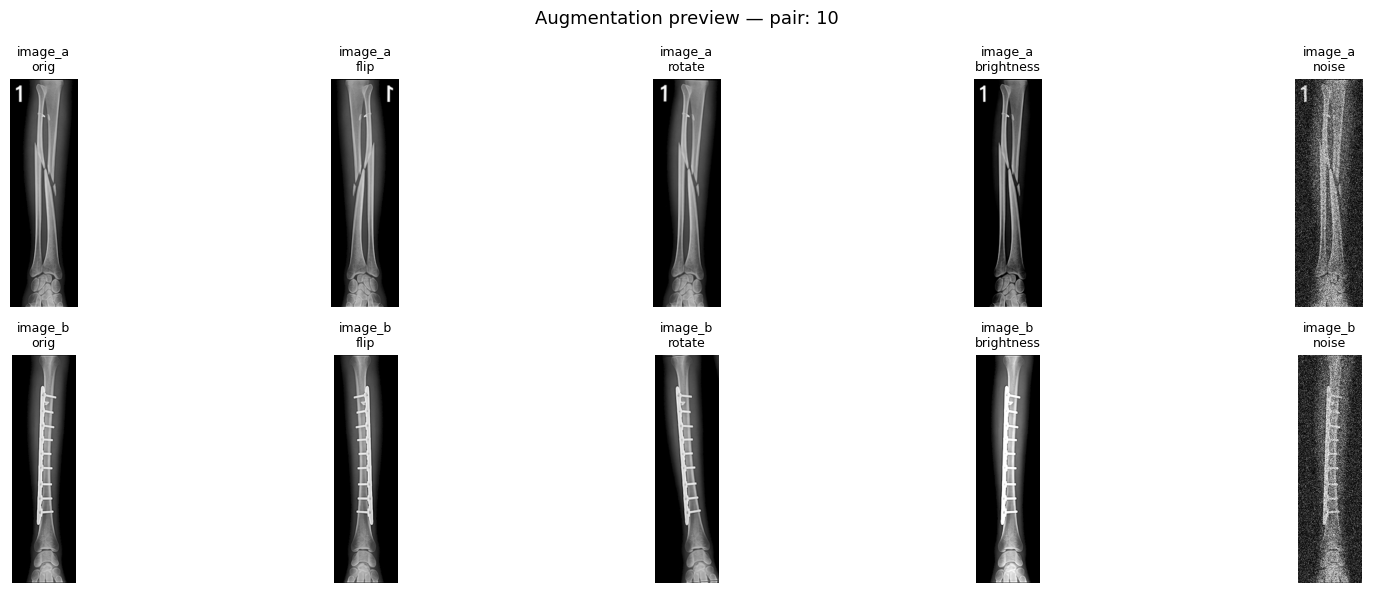

Preview saved to output folder.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ─────────────────────────────────────────────
# Count output files
# ─────────────────────────────────────────────
n_a = len([f for f in os.listdir(OUT_A) if f.endswith('.png')])
n_b = len([f for f in os.listdir(OUT_B) if f.endswith('.png')])

print(f'image_a output count : {n_a}')
print(f'image_b output count : {n_b}')
print(f'Pairs match          : {n_a == n_b}')

# ─────────────────────────────────────────────
# Visual check — pick first stem and show all augmentations
# ─────────────────────────────────────────────
stems = sorted(set(
    '_'.join(f.split('_')[:-1])  # strip aug suffix
    for f in os.listdir(OUT_A)
))

# Pick the first pair for preview
preview_stem = pairs[0][2]
suffixes = ['orig'] + [a['name'] for a in AUGMENTATIONS[:N_AUGMENTATIONS]]

fig, axes = plt.subplots(2, len(suffixes), figsize=(18, 6))
fig.suptitle(f'Augmentation preview — pair: {preview_stem}', fontsize=13)

for col, suffix in enumerate(suffixes):
    fname = f'{preview_stem}_{suffix}.png'
    path_a_preview = os.path.join(OUT_A, fname)
    path_b_preview = os.path.join(OUT_B, fname)

    for row, (path, label) in enumerate([(path_a_preview, 'image_a'), (path_b_preview, 'image_b')]):
        ax = axes[row][col]
        if os.path.exists(path):
            ax.imshow(mpimg.imread(path), cmap='gray')
        else:
            ax.text(0.5, 0.5, 'Not found', ha='center', va='center')
        ax.set_title(f'{label}\n{suffix}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmentation_preview.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Preview saved to output folder.')

## Step 8 — Summary

| | Count |
|---|---|
| Original pairs | 91 |
| Augmented copies per pair | 4 |
| **Total pairs after augmentation** | **~455** |
